In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = {
    'Feature_1': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Feature_2': [2, 4, 6, 8, 10, 12, 14, 16, 18, 20],
    'Target': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
}

df = pd.DataFrame(data)

df

,Feature_1,Feature_2,Target
0,1,2,3
1,2,4,5
2,3,6,7
3,4,8,9
4,5,10,11
5,6,12,13
6,7,14,15
7,8,16,17
8,9,18,19
9,10,20,21


In [3]:
X = df[['Feature_1', 'Feature_2']]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8
Testing samples: 2


In [4]:
linear_model = LinearRegression()
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=0.1)

linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

print("Linear Regression trained successfully.")
print("Ridge Regression trained successfully.")
print("Lasso Regression trained successfully.")

Linear Regression trained successfully.
Ridge Regression trained successfully.
Lasso Regression trained successfully.


In [5]:
linear_pred = linear_model.predict(X_test)
ridge_pred = ridge_model.predict(X_test)
lasso_pred = lasso_model.predict(X_test)

print("Actual Values:")
print(y_test.values)

print("\nLinear Regression Predictions:")
print(linear_pred)

print("\nRidge Regression Predictions:")
print(ridge_pred)

print("\nLasso Regression Predictions:")
print(lasso_pred)

Actual Values:
[19  5]

Linear Regression Predictions:
[19.  5.]

Ridge Regression Predictions:
[18.97594502  5.02405498]

Lasso Regression Predictions:
[18.97586207  5.02413793]


In [6]:
linear_mse = mean_squared_error(y_test, linear_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)

linear_r2 = r2_score(y_test, linear_pred)
ridge_r2 = r2_score(y_test, ridge_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Model Performance")
print("------------------")

print("Linear Regression  - MSE:", linear_mse, " R²:", linear_r2)
print("Ridge Regression   - MSE:", ridge_mse, " R²:", ridge_r2)
print("Lasso Regression   - MSE:", lasso_mse, " R²:", lasso_r2)

Model Performance
------------------
Linear Regression  - MSE: 7.888609052210118e-30  R²: 1.0
Ridge Regression   - MSE: 0.0005786421983679887  R²: 0.9999881909755435
Lasso Regression   - MSE: 0.0005826397146256251  R²: 0.9999881093935791


In [7]:
print("Linear Regression Coefficients:")
print(linear_model.coef_)

print("\nRidge Regression Coefficients:")
print(ridge_model.coef_)

print("\nLasso Regression Coefficients:")
print(lasso_model.coef_)

Linear Regression Coefficients:
[0.4 0.8]

Ridge Regression Coefficients:
[0.39862543 0.79725086]

Lasso Regression Coefficients:
[0.         0.99655172]


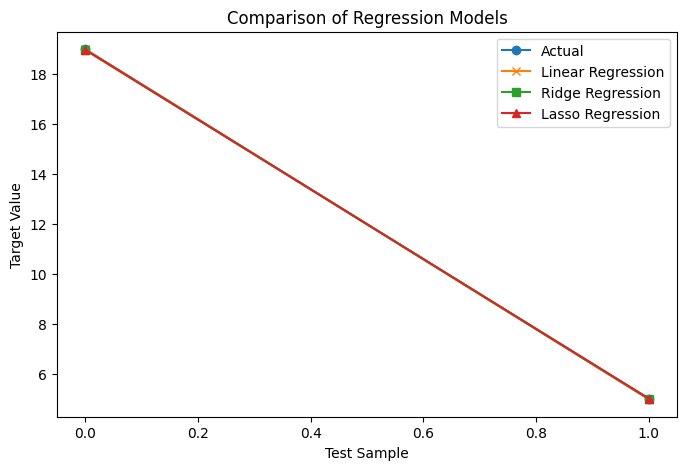

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(range(len(y_test)), y_test.values, marker='o', label='Actual')
plt.plot(range(len(y_test)), linear_pred, marker='x', label='Linear Regression')
plt.plot(range(len(y_test)), ridge_pred, marker='s', label='Ridge Regression')
plt.plot(range(len(y_test)), lasso_pred, marker='^', label='Lasso Regression')

plt.xlabel("Test Sample")
plt.ylabel("Target Value")
plt.title("Comparison of Regression Models")
plt.legend()

plt.show()